# ToolNode 를 사용 - 도구 사용하기
계산기, 날씨, 환율 도구

In [1]:
# 최근에는 모델에 툴을 바인딩하여 사용하게 하는 기능이 많이 추가되었습니다. 
# 랭그래프에서도 ToolNode라는 기능을 사용하여 LLM이 도구를 사용할 수 있습니다. 
# LLM 모델에 도구를 바인딩하여 사용자의 메시지에 따라 어떤 도구를 사용할지 결정하고, 
# 결정에 따라서 ToolNode에서 도구를 실행한 결과를 다시 LLM에게 넘긴 다음 해당 결과를 사용하여 최종 응답을 만들겠습니다. 
# 그래프의 형태는 다음 그림과 같습니다.

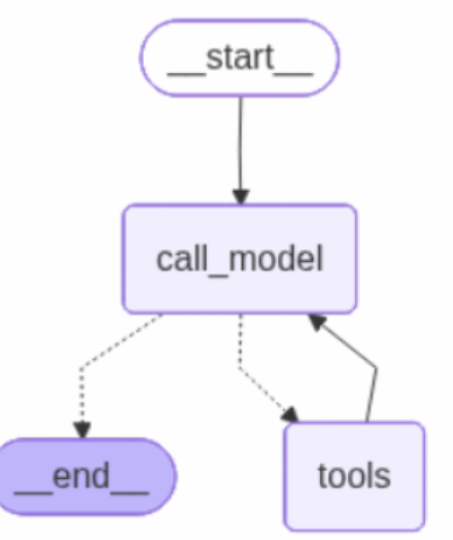

# import

In [2]:
from dotenv import load_dotenv
print(load_dotenv())

import math
from langchain_core.messages import HumanMessage, ToolMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from IPython.display import Image, display

True


In [3]:
# pip install geopy
from geopy.geocoders import Nominatim

# Nominatim geocoding class from the geopy library. 
# 주소를 좌표(위도, 경도)  혹은 좌표를 주소로 변환해두는 geocodging 라이브러리
# This class allows developers to convert addresses into geographic coordinates (latitude and longitude) and vice versa. 

In [4]:
import httpx  # http 클라이언트 라이브러리 (비동기/동기 요청 모두 가능. 사용법은 requests 와 거의 동일) 
from langgraph.prebuilt import ToolNode

In [5]:
# 다양한 AI 모델(ChatGPT, Claude, Gemini 등)을 일관된 방식으로 쉽게 생성하고 초기화할 수 있도록 도와주는 유틸리티 함수
from langchain.chat_models import init_chat_model

# 도구 Tools

## 계산기 도구

In [6]:
# eval() 함수 : 주어진 평가식을 실제 수행하고 계산 결과 리턴.

In [7]:
"1 + 1"

'1 + 1'

In [8]:
eval("1 + 1")

2

In [9]:
# 계산기 도구 함수

# Tool 함수의 docstring 은 LLM 에게 "이 도구가 언제 왜 어떻게 쓰여야 하는지" 를 알려주는 역할.
# ToolNode 는 docstring 을 프롬프트의 일부로 LLM 에게 전달.
def calculator(expression: str) -> str:
    """수학 계산을 수행합니다."""
    print(f"🟠계산 요청: {expression}")

    try:
        expression = expression.replace("sqrt", "math.sqrt")
        expression = expression.replace("sin", "math.sin")
        expression = expression.replace("cos", "math.cos")

        # 안전한 계산 실행
        # ※ eval() 은 파이썬 코드를 모드 실행할수 있기에, 위험한 실행동작을 예방하기 위해
        #    math 패키지만 사용하도록 제한.        
        result = eval(expression, {"__builtins__": {}, "math": math})
        
        return f"계산결과: {result}"
        
    except Exception as e:
        return f"💥계산오류: {e}"

    

In [10]:
calculator("11 * 3")

🟠계산 요청: 11 * 3


'계산결과: 33'

In [11]:
calculator("sin(3.14)")

🟠계산 요청: sin(3.14)


'계산결과: 0.0015926529164868282'

In [12]:
calculator("sqrt(2)")

🟠계산 요청: sqrt(2)


'계산결과: 1.4142135623730951'

## 날씨 정보 도구

In [13]:
def get_weather(city_name: str) -> dict:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""

    print(f"🟡날씨요청: {city_name}")

    if city_name:
        latitude, longitude = get_coordinates(city_name)
    else:
        raise ValueError("💢 City name 은 반드시 제공되어야 합니다!")

    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status()   # HTTP 에러응답시 예외 발생
    return response.json()


# 도시 이름을 받아서 (위도, 경도) 리턴
def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경로를 반환합니다"""

    geolocator = Nominatim(user_agent="weather_app")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    else:
        raise ValueError(f"💢Could not find coordinates for {city_name}")

In [14]:
get_coordinates("서울")

(37.5666791, 126.9782914)

In [15]:
get_coordinates("서울 강남구 테헤란로 146")

(37.5000198, 127.0355007)

In [16]:
get_weather("서울")

🟡날씨요청: 서울


{'latitude': 37.55,
 'longitude': 127.0,
 'generationtime_ms': 8.188843727111816,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 34.0,
 'current_weather_units': {'time': 'iso8601',
  'interval': 'seconds',
  'temperature': '°C',
  'windspeed': 'km/h',
  'winddirection': '°',
  'is_day': '',
  'weathercode': 'wmo code'},
 'current_weather': {'time': '2026-05-26T10:00',
  'interval': 900,
  'temperature': 23.5,
  'windspeed': 5.4,
  'winddirection': 70,
  'is_day': 1,
  'weathercode': 2}}

## 환율 계산 도구

In [24]:
from datetime import date
import FinanceDataReader as fdr

def currency_convertor(amount: float, from_currency: str, to_currency: str) -> str:
    """통화간 환율을 계산합니다"""
    print(f"🟣{amount} {from_currency} 를 {to_currency} 로 변환합니다")

    today = date.today().strftime('%Y-%m-%d')  # yyyy-MM-dd

    try: 
        df = fdr.DataReader(f'{from_currency.upper()}/{to_currency.upper()}', start=today)
        rate = df.tail(1)['Close'].item()
        converted = amount * rate
        return f"{amount} {from_currency} = {converted:.2f} {to_currency}"
    except:
        return f"{amount} {from_currency} = {amount} {to_currency} (동일통화)"
    

In [25]:
currency_convertor(100, "USD", "KRW")

🟣100 USD 를 KRW 로 변환합니다


'100 USD = 150408.00 KRW'

In [26]:
currency_convertor(100, "EUR", "KRW")

🟣100 EUR 를 KRW 로 변환합니다


'100 EUR = 175050.00 KRW'

In [27]:
currency_convertor(100, "JPY", "KRW")

🟣100 JPY 를 KRW 로 변환합니다


'100 JPY = 942.90 KRW'

In [28]:
currency_convertor(100, "CNY", "KRW")

🟣100 CNY 를 KRW 로 변환합니다


'100 CNY = 22176.20 KRW'

# 랭그래프 워크플로

## 분기 결정시 사용하는 노드

In [ ]:
# 조건부 라우팅에 사용할 함수
# 가장 마지막 메세지가 도구 호울 (tool_calls) 라면  tools 노드 이동
#  아니면 최종응답으로 종료

In [29]:
def should_continue(state: MessagesState):
    print("\n--- 분기 결정 ----")
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        print(f"결정: 도구 호출 필요 ({len(last_message.tool_calls)}개)")
        return "tools"
    else:
        print("결정: 최종 응답으로 종료")
        return END

## call_model 노드를 생성하는 함수

In [30]:
# 랭그래프의 노드로 사용하려면 State 매개변수 하나만! 갖고 있어야 한다.
# 추가적인 매개변수가 필요하다면? -> 다른 함수로 감싸서 노드 함수를 리턴하도록 해야 한다.

def create_call_model_function(model_with_tools):   # 매개변수가 State 가 아니다!
    """model_with_cools 를 사용하는 call_model 함수 생성"""

    def call_model(state: MessagesState):
        """LLM 을 호출하여 응답을 생성하는 노드 함수"""
        last_message = state['messages'][-1]

        # 도구 실행 결과를 받았는지 아니면 사용자 질문을 받았는지에 따라 분기
        if isinstance(last_message, ToolMessage):
            print("\n--- 모델 호출 (도구 결과 기반) ---")
            print(f"입력(도구결과): {last_message.content[:300]}...")
        else:
            print("\n--- 모델 호출 (사용자 질문 기반) ---")
            print(f"입력(사용자 메시지): {last_message.content}")     

        # 모델을 호출하여 다음 행동을 결정하게 함
        response = model_with_tools.invoke(state['messages'])

        # 모델의 결정에 따라 로그 출력
        if response.tool_calls:
            print(f"모델의 판단: 도구 호출 -> {response.tool_calls}")
        else:
            print(f"모델의 판단: 최종 답변 생성 -> {response.content}")

        return {"messages": [response]}

    return call_model
        



## 워크플로 생성 함수

In [ ]:
# 워크플로는 'START → call_model → [(도구를 사용해야 하면) tools call_model]-・END'가 됩니다. 

# • 유저가 메시지 입력
# • 모델에서 도구 호출이 필요한지 판단
# • 도구 호출이 필요하면 tool_node에서 도구 실행
# • 도구의 실행 결과를 받아서 모델에서 최종응답 생성
# • 최종 응답 출력

In [31]:
def create_graph(model_with_tools, tool_node):
    workflow = StateGraph(MessagesState)

    call_model = create_call_model_function(model_with_tools)
    workflow.add_node("call_model", call_model)
    workflow.add_node("tools", tool_node)

    workflow.add_edge(START, "call_model")
    workflow.add_conditional_edges(
        "call_model",
        should_continue,
        ["tools", END]   # list 형태로 매핑 제공 가능.
    )
    workflow.add_edge("tools", "call_model")

    return workflow.compile()

## 워크플로 생성 및 실행

In [35]:
def llm_tool_call(query: str):
    """하나의 질문에 대해 전체 LLM 워크플로우를 실행하고 로그를 출력"""

    # ToolNode 생성
    tools = [calculator, get_weather, currency_convertor]
    tool_node = ToolNode(tools)

    # 모델 with tools
    model = init_chat_model("gpt-4o", model_provider="openai")
    model_with_tools = model.bind_tools(tools)

    print(f"질문: {query}")
    print("-" * 50)

    # 워크플로우 생성
    app = create_graph(model_with_tools, tool_node)

    # 워크플로우 실행
    app.invoke({"messages": [HumanMessage(content=query)]})
    # 최종응답은 call_model 노드의 로그에서 출력될거다.

    print('-' * 50)
    print('처리완료')
    

# ----------------------------------------------------------------
test_queries = [
    # "2 + 3 * 4 를 계산해줘",   # calculator 도구 호출
    # "서울 날씨 어때?",    # get_weather 도구 호출
    # "100달러를 원화로 바꿔줘",  # currenc_converter 도구 호출

    "100 * 200 을 계산해주고 이 결과를 달러에서 원화로 바꿔줘",
]

for query in test_queries:
    try:
        llm_tool_call(query)
    except Exception as e:
        print(f"'{query}' 처리 중 오류 발생: {e}")

질문: 100 * 200 을 계산해주고 이 결과를 달러에서 원화로 바꿔줘
--------------------------------------------------

--- 모델 호출 (사용자 질문 기반) ---
입력(사용자 메시지): 100 * 200 을 계산해주고 이 결과를 달러에서 원화로 바꿔줘
모델의 판단: 도구 호출 -> [{'name': 'calculator', 'args': {'expression': '100 * 200'}, 'id': 'call_wh20Pb29mz3trSJJJyxqMEQa', 'type': 'tool_call'}]

--- 분기 결정 ----
결정: 도구 호출 필요 (1개)
🟠계산 요청: 100 * 200

--- 모델 호출 (도구 결과 기반) ---
입력(도구결과): 계산결과: 20000...
모델의 판단: 도구 호출 -> [{'name': 'currency_convertor', 'args': {'amount': 20000, 'from_currency': 'USD', 'to_currency': 'KRW'}, 'id': 'call_cueJ5qXn4i1z887Q2espnyrd', 'type': 'tool_call'}]

--- 분기 결정 ----
결정: 도구 호출 필요 (1개)
🟣20000.0 USD 를 KRW 로 변환합니다

--- 모델 호출 (도구 결과 기반) ---
입력(도구결과): 20000.0 USD = 30035200.20 KRW...
모델의 판단: 최종 답변 생성 -> 100 * 200의 결과는 20000입니다. 이 금액을 달러에서 원화로 변환하면 30,035,200.20 원이 됩니다.

--- 분기 결정 ----
결정: 최종 응답으로 종료
--------------------------------------------------
처리완료
